In [1]:
import pandas as pd
import numpy as np

In [2]:
#LOADING DATA

In [3]:
data = pd.read_excel('Strikers Performance Dataset.xlsx')
data.head()

,Striker_ID,Nationality,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,Hold-up Play,Aerial Duels Won,Defensive Contribution,Big Game Performance,Consistency,Penalty Success Rate,Impact on Team Performance,Off-field Conduct
0,1,Spain,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,50.921924,71.806409,15.682532,30.412215,6.152481,0.820314,0.922727,8.570370,11.451388
1,2,France,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,61.396150,53.726866,19.843983,26.474913,6.093172,0.803321,0.678984,3.444638,8.243689
2,3,Germany,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,65.863945,60.452227,20.090084,24.164116,3.408714,0.766540,0.843858,8.429491,9.506835
3,4,France,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,88.876877,60.511979,22.363152,44.129989,6.339820,0.611798,0.662997,6.532552,8.199653
4,5,France,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,75.565531,54.982158,13.165708,37.859323,8.465658,0.701638,0.906538,8.414915,6.665333


In [4]:
missing_values = data.isnull().sum()
print(missing_values)

Striker_ID                    0
Nationality                   0
Footedness                    0
Marital Status                0
Goals Scored                  0
Assists                       0
Shots on Target               0
Shot Accuracy                 0
Conversion Rate               0
Dribbling Success             0
Movement off the Ball         6
Hold-up Play                  0
Aerial Duels Won              0
Defensive Contribution        0
Big Game Performance          2
Consistency                   0
Penalty Success Rate          5
Impact on Team Performance    0
Off-field Conduct             0
dtype: int64


In [5]:
import sklearn as sk

In [6]:
from sklearn.impute import SimpleImputer

In [7]:
impute1 = SimpleImputer (strategy = 'mean')
impute1.fit(data[['Movement off the Ball']])
data[['Movement off the Ball']] = impute1.transform(data[['Movement off the Ball']])

In [8]:
impute2 = SimpleImputer(strategy='mean')
impute2.fit(data[['Big Game Performance']])
data[['Big Game Performance']] = impute2.transform(data[['Big Game Performance']])

In [9]:
impute3 = SimpleImputer (strategy = 'mean')
impute3.fit(data[['Penalty Success Rate']])
data[['Penalty Success Rate']] = impute3.transform(data[['Penalty Success Rate']])

In [10]:
missed_values = data.isnull().sum()
print(missed_values)

Striker_ID                    0
Nationality                   0
Footedness                    0
Marital Status                0
Goals Scored                  0
Assists                       0
Shots on Target               0
Shot Accuracy                 0
Conversion Rate               0
Dribbling Success             0
Movement off the Ball         0
Hold-up Play                  0
Aerial Duels Won              0
Defensive Contribution        0
Big Game Performance          0
Consistency                   0
Penalty Success Rate          0
Impact on Team Performance    0
Off-field Conduct             0
dtype: int64


In [12]:
data['Goals Scored'] = data['Goals Scored'].astype('int64')

In [13]:
data['Assists'] = data['Assists'].astype('int64')

In [14]:
data['Shots on Target'] = data['Shots on Target'].astype('int64')

In [15]:
data['Aerial Duels Won'] = data['Aerial Duels Won'].astype('int64')

In [16]:
from scipy.stats import yeojohnson

In [19]:
from scipy.stats import shapiro

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
def yeojohnson_transformation(data, column):
    transformed_data, lamda = yeojohnson(data[column])
    data[f'{column}_yeojohnson'] = transformed_data
    stat, p_value = shapiro(data[f'{column}_yeojohnson'])
    fig, axes = plt.subplots(1,1, figsize = (2,2))
    sns.kdeplot(data[f'{column}_yeojohnson'])
    print(lamda)
    print(p_value)

0.8395154649373938
0.10220220919599382


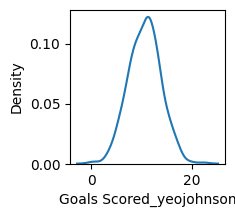

In [24]:
data['Goals Scored'] = yeojohnson_transformation(data, 'Goals Scored')

0.6798808711116654
0.4969481375369707


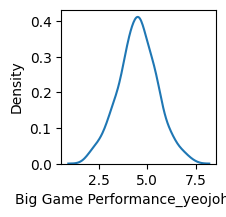

In [25]:
data['Big Game Performance'] = yeojohnson_transformation(data, 'Big Game Performance')

1.1263833257860194
0.0033412241999465765


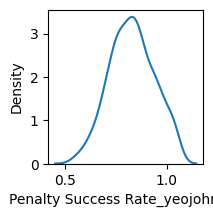

In [26]:
data['Penalty Success Rate'] = yeojohnson_transformation(data, 'Penalty Success Rate')

1.2279023208928552
0.10650885235674701


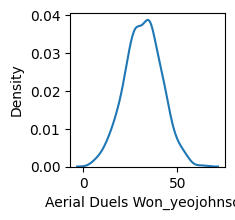

In [27]:
data['Aerial Duels Won'] = yeojohnson_transformation(data, 'Aerial Duels Won')

In [28]:
data = data.drop('Goals Scored', axis = 1)
data = data.drop('Big Game Performance', axis = 1)
data = data.drop('Penalty Success Rate', axis = 1)
data = data.drop('Aerial Duels Won', axis = 1)

In [29]:
data = data.rename(columns={'Goals Scored_yeojohnson': 'Goals Scored', 'Aerial Duels Won_yeojohnson': 'Aerial Duels Won', 'Big Game Performance_yeojohnson' : 'Big Game Performance', 'Penalty Success Rate_yeojohnson' : 'Penalty Success Rate'})

In [30]:
data['Goals Scored'] = data['Goals Scored'].astype('int64')

In [31]:
data['Aerial Duels Won'] = data['Aerial Duels Won'].astype('int64')

In [32]:
data['Total_Scores'] = data['Goals Scored'] + data['Shots on Target'] + data['Assists'] + data['Defensive Contribution'] + data['Dribbling Success'] + data['Aerial Duels Won'] + data['Impact on Team Performance'] + data['Consistency'] + data['Off-field Conduct'] + data['Big Game Performance'] + data['Movement off the Ball'] + data['Hold-up Play']
data.head()

,Striker_ID,Nationality,Footedness,Marital Status,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,Hold-up Play,Defensive Contribution,Consistency,Impact on Team Performance,Off-field Conduct,Goals Scored,Big Game Performance,Penalty Success Rate,Aerial Duels Won,Total_Scores
0,1,Spain,Left-footed,No,10,34,0.677836,0.166241,0.757061,50.921924,71.806409,30.412215,0.820314,8.570370,11.451388,12,4.133126,0.966221,23,257.872808
1,2,France,Left-footed,Yes,13,31,0.544881,0.192774,0.796818,61.396150,53.726866,26.474913,0.803321,3.444638,8.243689,10,4.101491,0.703687,31,243.987885
2,3,Germany,Left-footed,No,3,25,0.518180,0.160379,0.666869,65.863945,60.452227,24.164116,0.766540,8.429491,9.506835,12,2.562101,0.880783,33,245.412125
3,4,France,Right-footed,No,9,20,0.599663,0.184602,0.638776,88.876877,60.511979,44.129989,0.611798,6.532552,8.199653,15,4.232505,0.686629,37,294.734129
4,5,France,Left-footed,Yes,6,29,0.582982,0.105319,0.591485,75.565531,54.982158,37.859323,0.701638,8.414915,6.665333,9,5.309213,0.948646,19,253.089597


In [33]:
from scipy import stats

In [36]:
x = data.drop(['Striker_ID', 'Footedness', 'Marital Status', 'Total_Scores'], axis = 1)

In [39]:
x = x.drop(['Nationality'], axis = 1)

In [40]:
from sklearn.preprocessing import StandardScaler

In [41]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(x)

In [42]:
x.head()

,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,Hold-up Play,Defensive Contribution,Consistency,Impact on Team Performance,Off-field Conduct,Goals Scored,Big Game Performance,Penalty Success Rate,Aerial Duels Won
0,10,34,0.677836,0.166241,0.757061,50.921924,71.806409,30.412215,0.820314,8.570370,11.451388,12,4.133126,0.966221,23
1,13,31,0.544881,0.192774,0.796818,61.396150,53.726866,26.474913,0.803321,3.444638,8.243689,10,4.101491,0.703687,31
2,3,25,0.518180,0.160379,0.666869,65.863945,60.452227,24.164116,0.766540,8.429491,9.506835,12,2.562101,0.880783,33
3,9,20,0.599663,0.184602,0.638776,88.876877,60.511979,44.129989,0.611798,6.532552,8.199653,15,4.232505,0.686629,37
4,6,29,0.582982,0.105319,0.591485,75.565531,54.982158,37.859323,0.701638,8.414915,6.665333,9,5.309213,0.948646,19


In [43]:
from sklearn.decomposition import PCA

In [44]:
pca = PCA()
dimensionality_reduced_data = pca.fit_transform(scaled_data)

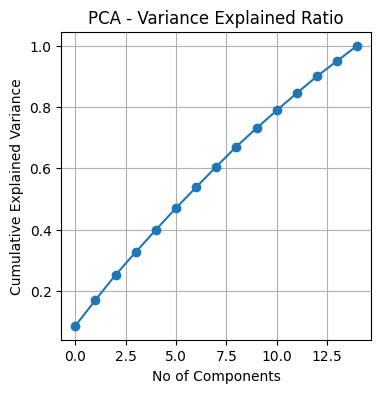

In [45]:
var_ratio = pca.explained_variance_ratio_
cum_var = np.cumsum(var_ratio)

plt.figure(figsize=(4,4))
plt.plot(cum_var, marker='o')
plt.xlabel("No of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Variance Explained Ratio")
plt.grid(True)
plt.show()

In [46]:
pca = PCA(n_components = 10)
dimensionality_reduced_data = pca.fit_transform(scaled_data)

In [47]:
from sklearn.cluster import KMeans

In [48]:
wcss = []
for K in range(1,11):
    kmeans = KMeans(n_clusters = K, random_state=42)
    kmeans.fit(dimensionality_reduced_data)
    wcss_values = kmeans.inertia_
    wcss.append(wcss_values)

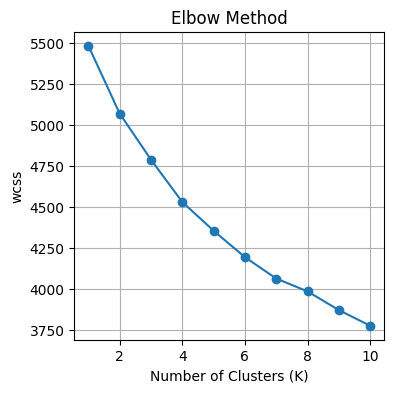

In [49]:
plt.figure(figsize=(4,4))
plt.plot(range(1,11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('wcss')
plt.title('Elbow Method')
plt.grid(True)
plt.show()

In [50]:
kmeans = KMeans(n_clusters = 6, random_state = 42)
Clusters = kmeans.fit_predict(dimensionality_reduced_data)

In [51]:
Clusters

array([1, 2, 0, 5, 1, 0, 1, 1, 0, 0, 3, 1, 3, 0, 3, 0, 4, 3, 2, 0, 0, 5,
       5, 4, 1, 1, 0, 4, 2, 0, 4, 1, 1, 3, 3, 3, 2, 5, 2, 3, 3, 4, 3, 2,
       4, 2, 4, 4, 2, 4, 1, 1, 2, 3, 0, 5, 4, 3, 1, 1, 0, 2, 2, 4, 1, 5,
       4, 3, 1, 4, 0, 3, 2, 0, 2, 0, 5, 1, 0, 2, 4, 3, 3, 5, 4, 2, 1, 2,
       3, 3, 5, 0, 4, 0, 3, 4, 0, 5, 5, 4, 2, 5, 4, 4, 3, 2, 5, 4, 5, 2,
       4, 3, 0, 1, 4, 5, 1, 3, 5, 5, 5, 2, 0, 2, 3, 5, 1, 4, 2, 0, 0, 3,
       2, 4, 5, 3, 3, 2, 0, 0, 5, 1, 2, 4, 3, 1, 0, 4, 3, 5, 2, 5, 2, 1,
       2, 1, 3, 2, 3, 4, 4, 0, 3, 2, 1, 2, 3, 1, 0, 4, 3, 5, 1, 3, 1, 3,
       1, 5, 4, 5, 0, 0, 1, 3, 3, 0, 4, 0, 5, 2, 4, 5, 4, 1, 3, 1, 2, 1,
       5, 2, 3, 5, 5, 5, 2, 2, 3, 5, 4, 3, 0, 1, 4, 0, 5, 0, 4, 1, 4, 5,
       1, 4, 0, 0, 2, 3, 2, 5, 0, 1, 3, 1, 5, 0, 5, 3, 4, 3, 2, 5, 5, 4,
       3, 5, 2, 5, 0, 4, 3, 1, 4, 5, 3, 0, 0, 0, 3, 4, 4, 1, 0, 4, 2, 0,
       2, 4, 1, 2, 4, 2, 3, 2, 5, 2, 0, 1, 0, 1, 0, 3, 4, 1, 3, 0, 1, 2,
       4, 3, 0, 4, 2, 2, 4, 5, 1, 3, 3, 3, 3, 1, 5,

In [52]:
clustered_data = pd.DataFrame(dimensionality_reduced_data, columns=[f'PC{K+1}' for K in range(dimensionality_reduced_data.shape[1])])
clustered_data['Clustered_Performance'] = Clusters

In [53]:
clustered_data.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Clustered_Performance
0,0.623713,-2.768314,0.959922,1.143427,-0.998282,-0.638324,0.124792,-0.872968,0.028494,-0.216865,1
1,-0.860199,1.077741,1.915175,1.093060,-1.533432,-0.434190,-0.106614,-1.070241,-0.612449,0.365276,2
2,0.753878,-0.696549,-1.053302,-0.264556,0.142590,-0.089833,-1.207795,-1.742414,-0.350864,-1.828599,0
3,-0.601375,1.471848,-1.356668,-1.329941,-0.707061,0.729986,0.167518,0.534871,0.507122,0.674417,5
4,-1.116010,-1.300984,-0.123249,-0.515166,1.562007,0.429282,-1.494809,-0.611176,-0.367707,0.761814,1


In [54]:
print("Cluster centers (PCA space):\n", kmeans.cluster_centers_)

Cluster centers (PCA space):
 [[-0.416987   -0.03315063 -0.20615043 -1.13508863  0.13462038  0.16842484
   0.03088997 -0.53879783  0.06077956 -0.58245234]
 [-0.28487368 -1.29827135 -0.49609496  0.45392005  0.43114908 -0.20780401
   0.11640164  0.37832998  0.32620999 -0.00177513]
 [-0.64942344  0.63973756  1.10112394  0.05621437  0.37351995 -0.11451832
   0.41667444  0.47527247 -0.33530974  0.26584411]
 [ 0.92450529 -0.21381731  0.62869591  0.02078327 -0.23617858 -0.77580881
  -0.74360277 -0.02299456  0.21593515  0.13071778]
 [ 1.18012128  0.26295744 -0.31628438  0.28454602  0.18897662  0.91697358
   0.37371685 -0.32495622 -0.0392804   0.12036286]
 [-0.74235302  0.64866807 -0.68882894  0.4346807  -0.86930641  0.03017161
  -0.15189656  0.09760565 -0.24386947  0.12574174]]


In [55]:
clustered_data['Total_Performance_Scores'] = clustered_data['PC1'] + clustered_data['PC2'] + clustered_data['PC3'] + clustered_data['PC4'] + clustered_data['PC5'] + clustered_data['PC6'] + clustered_data['PC7'] + clustered_data['PC8'] + clustered_data['PC9'] + clustered_data['PC10']

In [56]:
clusters_ranking = clustered_data.groupby('Clustered_Performance')['Total_Performance_Scores'].mean().sort_values(ascending=False)
print(clusters_ranking)

Clustered_Performance
4    2.647134
2    2.229135
3   -0.071765
1   -0.582808
5   -1.359387
0   -2.517912
Name: Total_Performance_Scores, dtype: float64


In [57]:
mapping = {4 : 'Top-Performing Strikers', 2 : '2nd Top-Performing Strikers', 3 : '3rd Top-Performing Strikers', 1 : '4th Top-Performing Strikers', 5 : '5th Top-Performing Strikers', 0 : '6th Top-Performing Strikers'}
clustered_data['Strikers_Performance'] = clustered_data['Clustered_Performance'].map(mapping)

In [58]:
clustered_data

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,Clustered_Performance,Total_Performance_Scores,Strikers_Performance
0,0.623713,-2.768314,0.959922,1.143427,-0.998282,-0.638324,0.124792,-0.872968,0.028494,-0.216865,1,-2.614406,4th Top-Performing Strikers
1,-0.860199,1.077741,1.915175,1.093060,-1.533432,-0.434190,-0.106614,-1.070241,-0.612449,0.365276,2,-0.165872,2nd Top-Performing Strikers
2,0.753878,-0.696549,-1.053302,-0.264556,0.142590,-0.089833,-1.207795,-1.742414,-0.350864,-1.828599,0,-6.337444,6th Top-Performing Strikers
3,-0.601375,1.471848,-1.356668,-1.329941,-0.707061,0.729986,0.167518,0.534871,0.507122,0.674417,5,0.090716,5th Top-Performing Strikers
4,-1.116010,-1.300984,-0.123249,-0.515166,1.562007,0.429282,-1.494809,-0.611176,-0.367707,0.761814,1,-2.775998,4th Top-Performing Strikers
...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0.855302,0.021016,0.360190,-1.043323,-1.529516,2.044755,0.742559,-0.803011,1.545440,-1.093567,4,1.099846,Top-Performing Strikers
496,-1.732348,-0.411411,2.127478,0.573495,-0.120144,1.334352,-0.205932,-1.026815,1.542249,0.843627,2,2.924550,2nd Top-Performing Strikers
497,-0.838581,-0.196694,-0.560447,-0.499226,1.996008,0.354517,1.946898,0.188556,2.716315,0.054489,1,5.161834,4th Top-Performing Strikers
498,0.902670,0.518885,0.575286,3.315206,-0.664147,2.597809,-1.036837,0.420672,0.432097,-1.485296,4,5.576346,Top-Performing Strikers


In [59]:
from sklearn.metrics import silhouette_score

score = silhouette_score(dimensionality_reduced_data, Clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.07213104677786031


In [60]:
from sklearn.metrics import davies_bouldin_score
dbi = davies_bouldin_score(dimensionality_reduced_data, Clusters)
print("Davies-Bouldin Index:", dbi)

Davies-Bouldin Index: 2.393596939185216
